#### how the hierarchy works:

#### focus:
##### identifying critically endangered species in Singapore, with focus on the Sunda Pangolin, the Raffles' Banded Langur, & the Leopard Cat

##### input tensors: 100 images of birds, monkeys, cats, & anteaters
##### target tensors: 100 images classified into its animal type, sub-animal type, & species


#### Imports & Configurations 

In [13]:
# import necessary libraries/dependencies 
import matplotlib.pyplot as plt
import numpy as np
import os
import urllib.request
import PIL
from PIL import Image
from io import BytesIO
import pathlib
import requests

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [14]:
# pull dataset from URL using RISON
api_url = "https://api.inaturalist.org/v2/observations?photos=true&photo_license=cc0,cc-by&fields=(id:!t,photos:(id:!t,url:!t,license_code:!t,attribution:!t))"
# api_url = "https://api.inaturalist.org/v2/observations?fields=all"


# GET request to URL
response = requests.get(api_url)

# status code for HTTPS
print(response.status_code)

# inspect first index result
data = response.json()
print(data["results"][0])

200
{'uuid': 'c9f2f126-6f4e-48f7-b1e7-77812ee92846', 'id': 397115650, 'photos': [{'id': 728321138, 'url': 'https://inaturalist-open-data.s3.amazonaws.com/photos/728321138/square.jpg', 'license_code': 'cc-by', 'attribution': '(c) Pam Hardy, some rights reserved (CC BY)'}, {'id': 728321132, 'url': 'https://inaturalist-open-data.s3.amazonaws.com/photos/728321132/square.jpg', 'license_code': 'cc-by', 'attribution': '(c) Pam Hardy, some rights reserved (CC BY)'}, {'id': 728321134, 'url': 'https://inaturalist-open-data.s3.amazonaws.com/photos/728321134/square.jpg', 'license_code': 'cc-by', 'attribution': '(c) Pam Hardy, some rights reserved (CC BY)'}]}


In [15]:
photo = data["results"][0]["photos"][0]
print(photo.keys())

dict_keys(['id', 'url', 'license_code', 'attribution'])


In [16]:
# replacing square.jpg with medium.jpg for better quality
if "url" in photo.keys():
    new_url = photo["url"].replace("square", "medium")

print(new_url)

https://inaturalist-open-data.s3.amazonaws.com/photos/728321138/medium.jpg


In [17]:
# fetch image
animal_image = requests.get(new_url)
print(animal_image.status_code)
print(animal_image.headers.get("content-type"))

200
image/jpeg


#### Define Image Data specifications 

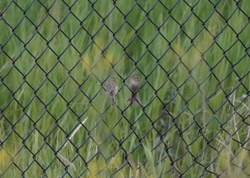

In [30]:
# preprocess & show image
image = Image.open(BytesIO(animal_image.content))

w, h = image.size
new_w = 250
new_h = int(h * (new_w / w))

image = image.convert("RGB")
image = image.resize((new_w, new_h))

display(image)

In [32]:
# convert image into Numpy array
image_arr = np.array(image)
print(image_arr.shape)

(178, 250, 3)


This shows that the image is a 3D tensor, & has a height of 178, width of 250, & 3 colour channels (RGB).

In [33]:
# check pixel range
print("data type: %s" % image_arr.dtype)
print("min: %.3f, max: %.3f" % (image_arr.min(), image_arr.max()))

data type: uint8
min: 6.000, max: 218.000


In [35]:
# normalisation on image
pixels = image_arr.astype("float32")
pixels /= 255.0
print("min: %.3f, max: %.3f" % (pixels.min(), pixels.max()))

min: 0.024, max: 0.855
